# 0.1 Summary
This notebook explores the data input format and creates a CNN to predict redshift

Dataset from https://zenodo.org/records/11117528
The site requests we cite: https://arxiv.org/abs/2410.00271

Main idea:
* Images are in the shape of 5 x 64 x 64 (per galaxy)
* 5 channels are (g, r, i, z, y) which are just different light bands
  * (how do we convert these to rgb?
* The import value in the datset is called the spectroscopic redshift value


# 0.2 Imports
Keys in the HDF5 file '/content/data/5x64x64_testing_reduced_tiny.hdf5':
* image: This is the core data. It represents the actual galaxy images. The shape (250, 5, 64, 64) tells us there are 250 individual galaxy images. Each image has 5 channels (the different light bands: g, r, i, z, y, as you noted), and each channel is a 64x64 pixel array. These are the visual inputs you'll use for analysis or a machine learning model.

* object_id: This is a unique identifier for each astronomical object (galaxy) in the dataset. It allows you to keep track of individual galaxies and link them to other data or external catalogs if needed. It's usually a large integer.

* source_index: This often refers to the original index or position of the object within a larger source catalog or survey. It's another identifier that can be useful for tracing back the origin of the data or for internal indexing purposes within the HDF5 file.

* specz_redshift (Spectroscopic Redshift): This is a crucial astrophysical measurement. Redshift indicates how much the light from a galaxy has been stretched to longer (redder) wavelengths due to the expansion of the universe. It's directly related to the galaxy's distance from us and how fast it's moving away. A spectroscopic redshift is measured by analyzing spectral lines, making it a very precise and reliable measurement, often considered the 'ground truth' for galaxy distance/velocity. This is likely your target variable if you're building a model to predict redshift from image data.

In [ ]:
import h5py
import numpy as np

file_path = '/content/data/5x64x64_testing_reduced_tiny.hdf5'

# Load all data into memory
with h5py.File(file_path, 'r') as f:
    images = f['image'][()]
    object_ids = f['object_id'][()]
    source_indices = f['source_index'][()]
    specz_redshifts = f['specz_redshift'][()]

print(f"\nVariable: images")
print(f"  Shape: {images.shape}")
print(f"  Dtype: {images.dtype}")

print(f"\nVariable: object_ids")
print(f"  Shape: {object_ids.shape}")
print(f"  Dtype: {object_ids.dtype}")

print(f"\nVariable: source_indices")
print(f"  Shape: {source_indices.shape}")
print(f"  Dtype: {source_indices.dtype}")

print(f"\nVariable: specz_redshifts")
print(f"  Shape: {specz_redshifts.shape}")
print(f"  Dtype: {specz_redshifts.dtype}")
print(f"  Sample (first 5): {specz_redshifts[:5]}\n")

--- Data Loaded ---

Variable: images
  Shape: (250, 5, 64, 64)
  Dtype: float32
  Sample (first image, first channel):
[[-0.04117213  0.05909605  0.00246585 ... -0.00677365 -0.02365039
   0.02111592]
 [-0.03334548  0.01484894  0.07441016 ...  0.02722547  0.00718886
   0.03472073]
 [-0.01894368  0.00282642  0.03994996 ...  0.05250556  0.05741201
   0.00907845]
 ...
 [-0.02251505  0.00107532 -0.0118744  ... -0.02195847 -0.05462221
  -0.03419105]
 [-0.03681326 -0.00414465  0.02875158 ...  0.06068506 -0.01791123
   0.0278918 ]
 [ 0.0965034   0.03472126  0.00218849 ...  0.04184021  0.01590953
  -0.01530726]]


Variable: object_ids
  Shape: (250,)
  Dtype: int64
  Sample (first 5): [36407063378678903 36407187932710008 36407187932722372 36407187932722754
 36407187932723360]


Variable: source_indices
  Shape: (250,)
  Dtype: int64
  Sample (first 5): [0 1 2 3 4]


Variable: specz_redshifts
  Shape: (250,)
  Dtype: float32
  Sample (first 5): [0.31652 0.56769 0.53428 0.11878 0.23497]



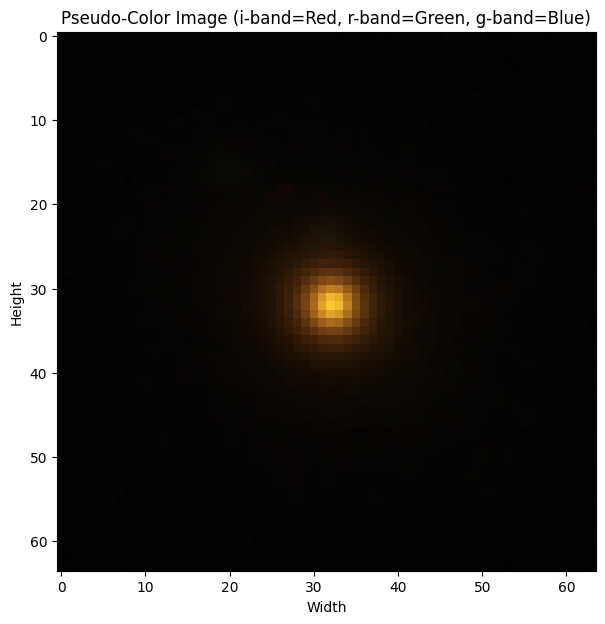

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

file_path = '/content/data/5x64x64_testing_reduced_tiny.hdf5'

with h5py.File(file_path, 'r') as f:
    images_data = f['image']

    # Select the first image (all 5 channels)
    first_image_all_channels = images_data[0, :, :, :]

    # testing out varying
    img_rgb = np.transpose(first_image_all_channels[[2, 1, 0], :, :], (1, 2, 0))

    # Normalize the pixel values for display (imshow expects values typically between 0-1 or 0-255)
    # We'll normalize each channel independently for better contrast, or you can normalize globally.
    # For this example, a global min-max normalization across the selected channels is used.
    min_val = img_rgb.min()
    max_val = img_rgb.max()
    if (max_val - min_val) == 0:
        # Handle case where all values are the same to avoid division by zero
        normalized_img_rgb = np.zeros_like(img_rgb) # Or just keep as is, but this ensures 0-1 range
    else:
        normalized_img_rgb = (img_rgb - min_val) / (max_val - min_val)

    plt.figure(figsize=(7, 7))
    plt.imshow(normalized_img_rgb) # imshow automatically infers RGB if shape is (H, W, 3)
    plt.title('Pseudo-Color Image (i-band=Red, r-band=Green, g-band=Blue)')
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.show()


In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

file_path = '/content/data/5x64x64_testing_reduced_tiny.hdf5'

with h5py.File(file_path, 'r') as f:
    images_data = f['image']

    # Select the first image (all 5 channels)
    first_image_all_channels = images_data[0, :, :, :]

    # testing
    img_rgb = np.transpose(first_image_all_channels[[2, 1, 0], :, :], (1, 2, 0))

    # Apply arcsinh stretch for better dynamic range visualization
    # The factor of 10 is a common choice for astronomical images.
    stretched_img_rgb = np.arcsinh(img_rgb * 10) / np.arcsinh(10)

    # Clip values to ensure they are within the displayable range [0, 1]
    normalized_img_rgb = np.clip(stretched_img_rgb, 0, 1)

    plt.figure(figsize=(7, 7))
    plt.imshow(normalized_img_rgb) # imshow automatically infers RGB if shape is (H, W, 3)
    plt.title('Pseudo-Color Image (i-band=Red, r-band=Green, g-band=Blue) with Arcsinh Stretch')
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/data/5x64x64_testing_reduced_tiny.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming normalized_img_rgb is available from the previous cell's execution
# Flatten the RGB image to a 1D array of pixel values
flattened_pixels = normalized_img_rgb.flatten()

plt.figure(figsize=(10, 6))
plt.hist(flattened_pixels, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Pixel Values in Arcsinh Stretched Image')
plt.xlabel('Pixel Intensity (Normalized)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'normalized_img_rgb' is not defined


--- Normalizing Images (per-channel) ---
Channel means: [0.1484804  0.36797866 0.5983555  0.7906501  0.97779566]
Channel stds: [0.77569014 1.697862   2.7441509  3.7246163  4.1347218 ]
Shape of normalized images: (250, 5, 64, 64)
Sample of normalized image (first channel, first image):
[[-0.24449523 -0.11523203 -0.18823825 -0.23285833 -0.16174161]
 [-0.2344053  -0.17227429 -0.09548946 -0.1953905  -0.2139759 ]
 [-0.21583886 -0.1877734  -0.13991468 -0.09852376 -0.12278951]
 [-0.19765401 -0.2023924  -0.22205514 -0.14438686 -0.07053021]
 [-0.17111003 -0.18363464 -0.12475573 -0.15218905 -0.06352104]]

--- Splitting Data into Train, Validation, Test Sets ---
Train set size: 174 samples
Validation set size: 38 samples
Test set size: 38 samples

--- Creating PyTorch Dataset Class ---
Train Dataset: 174 samples
Validation Dataset: 38 samples
Test Dataset: 38 samples

--- Creating PyTorch DataLoaders ---
Train DataLoader batch size: 32
Validation DataLoader batch size: 32
Test DataLoader batch s

In [35]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import h5py
from einops import rearrange

# Define file paths for each dataset split
file_path_train = '/content/data/5x64x64_training_reduced_tiny.hdf5'
file_path_val = '/content/data/5x64x64_validation_reduced_tiny.hdf5'
file_path_test = '/content/data/5x64x64_testing_reduced_tiny.hdf5'

# Load Data for Each Split
print("Loading training data...")
with h5py.File(file_path_train, 'r') as f:
    images_train = f['image'][()]
    specz_redshifts_train = f['specz_redshift'][()]
print(f"Training data loaded. Shape: {images_train.shape}, Redshifts shape: {specz_redshifts_train.shape}")

print("Loading validation data...")
with h5py.File(file_path_val, 'r') as f:
    images_val = f['image'][()]
    specz_redshifts_val = f['specz_redshift'][()]
print(f"Validation data loaded. Shape: {images_val.shape}, Redshifts shape: {specz_redshifts_val.shape}")

print("Loading testing data...")
with h5py.File(file_path_test, 'r') as f:
    images_test = f['image'][()]
    specz_redshifts_test = f['specz_redshift'][()]
print(f"Testing data loaded. Shape: {images_test.shape}, Redshifts shape: {specz_redshifts_test.shape}")

# Per-channel Normalization (using stats from training data only)
print("\n--- Normalizing Images (per-channel using training stats) ---")
# Calculate mean and standard deviation for each channel across training images
# images_train.shape = (num_samples, channels, height, width)
# mean/std will be (channels,)
channel_means = images_train.mean(axis=(0, 2, 3))
channel_stds = images_train.std(axis=(0, 2, 3))

print(f"Channel means (from training data): {channel_means}")
print(f"Channel stds (from training data): {channel_stds}")

# Normalize all datasets using the means and stds calculated from the training data
normalized_images_train = (images_train - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')
normalized_images_val = (images_val - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')
normalized_images_test = (images_test - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')

print(f"Shape of normalized training images: {normalized_images_train.shape}")
print(f"Shape of normalized validation images: {normalized_images_val.shape}")
print(f"Shape of normalized testing images: {normalized_images_test.shape}")
print(f"Sample of normalized training image (first channel, first image):\n{normalized_images_train[0, 0, :5, :5]}")

# Data Preparation
print("\n--- Data Loaded and Normalized ---")
print(f"Train set size: {len(normalized_images_train)} samples")
print(f"Validation set size: {len(normalized_images_val)} samples")
print(f"Test set size: {len(normalized_images_test)} samples")

# Create a PyTorch Dataset
print("\n--- Creating PyTorch Dataset Class ---")

class GalaxyDataset(Dataset):
    def __init__(self, images, redshifts):
        self.images = images
        self.redshifts = redshifts

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Convert numpy arrays to PyTorch tensors
        image = torch.from_numpy(self.images[idx]).float()
        redshift = torch.tensor(self.redshifts[idx]).float()
        return image, redshift

# Create dataset instances for each split
train_dataset = GalaxyDataset(normalized_images_train, specz_redshifts_train)
val_dataset = GalaxyDataset(normalized_images_val, specz_redshifts_val)
test_dataset = GalaxyDataset(normalized_images_test, specz_redshifts_test)

print(f"Train Dataset: {len(train_dataset)} samples")
print(f"Validation Dataset: {len(val_dataset)} samples")
print(f"Test Dataset: {len(test_dataset)} samples")

# DataLoaders
print("\n--- Creating PyTorch DataLoaders ---")

batch_size = 32 # You can adjust this batch size

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train DataLoader batch size: {train_dataloader.batch_size}")
print(f"Validation DataLoader batch size: {val_dataloader.batch_size}")
print(f"Test DataLoader batch size: {test_dataloader.batch_size}")

# Verify a batch from the training dataloader
print("\n--- Verifying a batch from Train DataLoader ---")
for images_batch, redshifts_batch in train_dataloader:
    print(f"Batch of images shape: {images_batch.shape}") # Expected: (batch_size, channels, height, width)
    print(f"Batch of redshifts shape: {redshifts_batch.shape}") # Expected: (batch_size,)
    print(f"Sample image from batch (first image, first channel):\n{images_batch[0, 0, :5, :5]}")
    print(f"Sample redshift from batch: {redshifts_batch[0]}")
    break # Just get one batch for verification

Loading training data...


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/data/5x64x64_training_reduced_tiny.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RedshiftCNN(nn.Module):
    def __init__(self):
        super(RedshiftCNN, self).__init__()
        # Input: 5 channels, 64x64 image
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(in_channels=5, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (32, 32, 32)

        # Convolutional Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (64, 16, 16)

        # Convolutional Block 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (128, 8, 8)

        # Convolutional Block 4
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (256, 4, 4)

        # Fully Connected Layers
        # Calculate the size of the flattened features: 256 channels * 4 * 4 pixels
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 1) # Output a single redshift value

    def forward(self, x):
        # Apply Conv -> ReLU -> Pool for each block
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))

        # Flatten the output for the fully connected layers
        x = torch.flatten(x, 1) # Flatten all dimensions except batch

        # Apply Fully Connected layers with ReLU activation
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = RedshiftCNN()
print(model)

# Test with a dummy input
dummy_input = torch.randn(1, 5, 64, 64) # Batch size 1, 5 channels, 64x64
output = model(dummy_input)
print(f"\nDummy input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Sample output (redshift prediction): {output.item()}")

RedshiftCNN(
  (conv1): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

Dummy input shape: torch.Size([1, 5, 64, 64])
Output shape: torch.Size([1, 1])
Sample output (redshift prediction): -0.00917939655482769


In [36]:
import h5py
import numpy as np

file_path_medium_train = '/content/data/5x64x64_training_reduced_medium.hdf5'

print(f"Loading medium training data from: {file_path_medium_train}")
with h5py.File(file_path_medium_train, 'r') as f:
    images_medium_train = f['image'][()]
    specz_redshifts_medium_train = f['specz_redshift'][()]
print(f"Medium training data loaded. Shape: {images_medium_train.shape}")

# Calculate mean and standard deviation for each channel
# images_medium_train.shape = (num_samples, channels, height, width)
# mean/std will be (channels,)
channel_means_medium = images_medium_train.mean(axis=(0, 2, 3))
channel_stds_medium = images_medium_train.std(axis=(0, 2, 3))

print("\n--- Channel Statistics for Medium Training Dataset ---")
print(f"Channel means: {channel_means_medium}")
print(f"Channel stds: {channel_stds_medium}")

Loading medium training data from: /content/data/5x64x64_training_reduced_medium.hdf5
Medium training data loaded. Shape: (10000, 5, 64, 64)

--- Channel Statistics for Medium Training Dataset ---
Channel means: [0.21533734 0.45367402 0.68543416 0.8832283  1.0558323 ]
Channel stds: [1.0022058 1.9175421 3.0707815 3.8724658 4.5129385]


In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.MSELoss() # Using Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model and data moved to: {device}")
print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__} with learning rate {optimizer.param_groups[0]['lr']}")

Model and data moved to: cpu
Loss function: MSELoss
Optimizer: Adam with learning rate 0.001


Now, let's define the training and validation loops. We'll train the model for a few epochs and keep track of the loss on both the training and validation sets to monitor for overfitting.

Epoch 1/10, Train Loss: 1.0790, Val Loss: 0.7769
Epoch 2/10, Train Loss: 0.5440, Val Loss: 0.4892
Epoch 3/10, Train Loss: 0.4196, Val Loss: 0.5162
Epoch 4/10, Train Loss: 0.3515, Val Loss: 0.4031
Epoch 5/10, Train Loss: 0.3018, Val Loss: 0.3953
Epoch 6/10, Train Loss: 0.2689, Val Loss: 0.3272
Epoch 7/10, Train Loss: 0.2294, Val Loss: 0.3172
Epoch 8/10, Train Loss: 0.2298, Val Loss: 0.3470
Epoch 9/10, Train Loss: 0.2293, Val Loss: 0.3302
Epoch 10/10, Train Loss: 0.2322, Val Loss: 0.3314

Training complete!


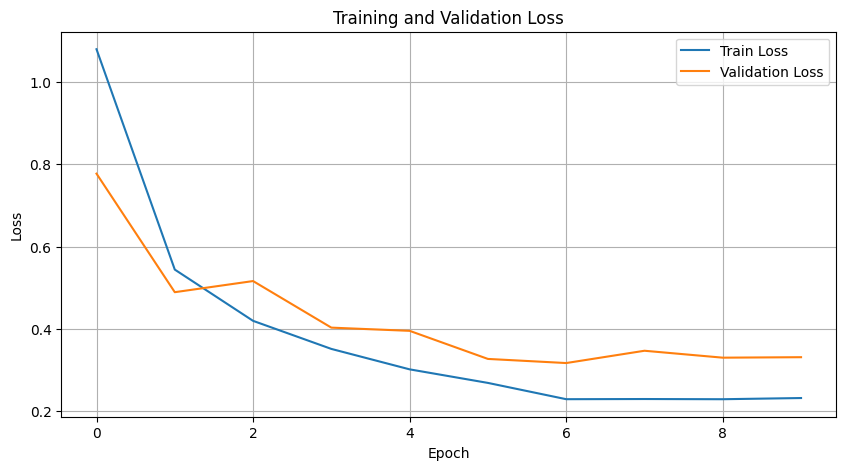

In [ ]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, redshifts in train_dataloader:
        images, redshifts = images.to(device), redshifts.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs.squeeze(), redshifts)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, redshifts in val_dataloader:
            images, redshifts = images.to(device), redshifts.to(device)
            outputs = model(images)
            loss = criterion(outputs.squeeze(), redshifts)
            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')

print('\nTraining complete!')

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 5. Model Evaluation

Now, let's evaluate the trained model on the test set. We will compute the predictions, plot true vs. predicted redshifts, and calculate some common photo-z metrics such as bias, outlier fraction, and normalized median absolute deviation (NMAD).


--- Test Set Evaluation ---
Number of test samples: 38


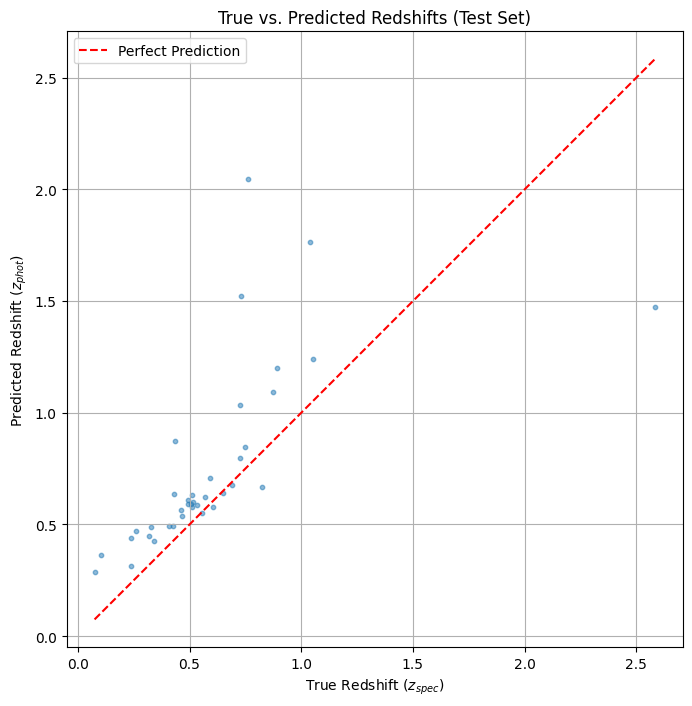


Photo-z Metrics:
  Bias (mean(z_phot - z_spec)): 0.1519
  Outlier Fraction (|(z_phot - z_spec)|/(1+z_spec) > 0.15): 0.2895
  NMAD Scatter: 0.0598

Standard Regression Metrics:
  Mean Squared Error (MSE): 0.1299
  Mean Absolute Error (MAE): 0.2216


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set the model to evaluation mode
model.eval()

all_predictions = []
all_true_redshifts = []

with torch.no_grad():
    for images, redshifts in test_dataloader:
        images = images.to(device)
        outputs = model(images)
        all_predictions.extend(outputs.squeeze().cpu().numpy())
        all_true_redshifts.extend(redshifts.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_redshifts = np.array(all_true_redshifts)

print("\n--- Test Set Evaluation ---")
print(f"Number of test samples: {len(all_true_redshifts)}")

# Plot: True vs. Predicted Redshifts
plt.figure(figsize=(8, 8))
plt.scatter(all_true_redshifts, all_predictions, alpha=0.5, s=10)
plt.plot([min(all_true_redshifts), max(all_true_redshifts)],
         [min(all_true_redshifts), max(all_true_redshifts)],
         '--r', label='Perfect Prediction')
plt.xlabel('True Redshift ($z_{spec}$)')
plt.ylabel('Predicted Redshift ($z_{phot}$)')
plt.title('True vs. Predicted Redshifts (Test Set)')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Calculate Photo-z Metrics

# Bias: Mean difference (predicted - true)
bias = np.mean(all_predictions - all_true_redshifts)

# Delta_z: Used for outlier fraction and NMAD
delta_z_norm = (all_predictions - all_true_redshifts) / (1 + all_true_redshifts)

# Outlier fraction: |(z_phot - z_spec)| / (1 + z_spec) > 0.15
outlier_threshold = 0.15
outlier_fraction = np.sum(np.abs(delta_z_norm) > outlier_threshold) / len(all_true_redshifts)

# NMAD (Normalized Median Absolute Deviation) scatter
# NMAD = 1.4826 * median(|delta_z_norm - median(delta_z_norm)|)
median_delta_z_norm = np.median(delta_z_norm)
NMAD = 1.4826 * np.median(np.abs(delta_z_norm - median_delta_z_norm))

print(f"\nPhoto-z Metrics:")
print(f"  Bias (mean(z_phot - z_spec)): {bias:.4f}")
print(f"  Outlier Fraction (|(z_phot - z_spec)|/(1+z_spec) > {outlier_threshold}): {outlier_fraction:.4f}")
print(f"  NMAD Scatter: {NMAD:.4f}")

# Basic regression metrics
mse = mean_squared_error(all_true_redshifts, all_predictions)
mae = mean_absolute_error(all_true_redshifts, all_predictions)
print(f"\nStandard Regression Metrics:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")

<>:69: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:85: SyntaxWarning: invalid escape sequence '\D'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:100: SyntaxWarning: invalid escape sequence '\D'
<>:107: SyntaxWarning: invalid escape sequence '\D'
<>:114: SyntaxWarning: invalid escape sequence '\D'
<>:121: SyntaxWarning: invalid escape sequence '\D'
<>:132: SyntaxWarning: invalid escape sequence '\D'
<>:137: SyntaxWarning: invalid escape sequence '\D'
<>:154: SyntaxWarning: invalid escape sequence '\D'
<>:159: SyntaxWarning: invalid escape sequence '\D'
<>:69: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:85: SyntaxWarning: invalid escape sequence '\D'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:100: SyntaxWarning: invalid escape sequence '\D'
<>:107: SyntaxWarning: invalid escape sequence '\D'
<>:114: SyntaxWarning: invalid escape sequence '\D'
<>:121: SyntaxWarnin

--- Visualizing 3 Best and 3 Worst Predicted Galaxies (With Arcsinh Stretch) ---


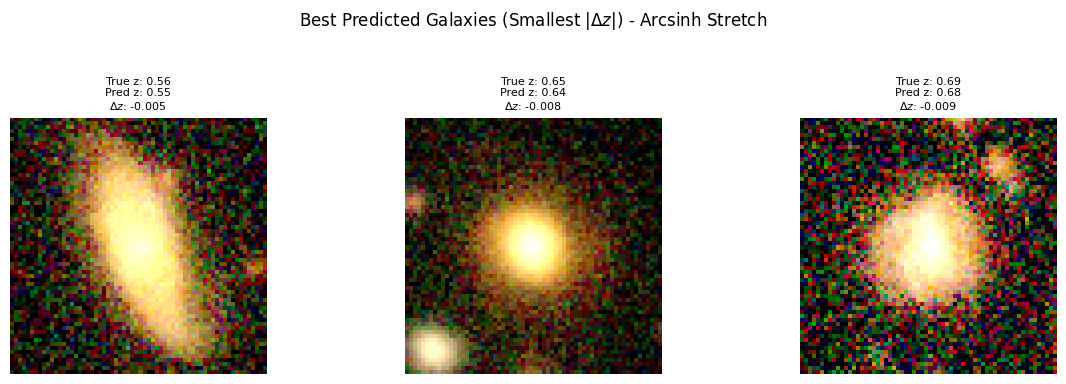


--- Visualizing 3 Best and 3 Worst Predicted Galaxies (Without Arcsinh Stretch) ---


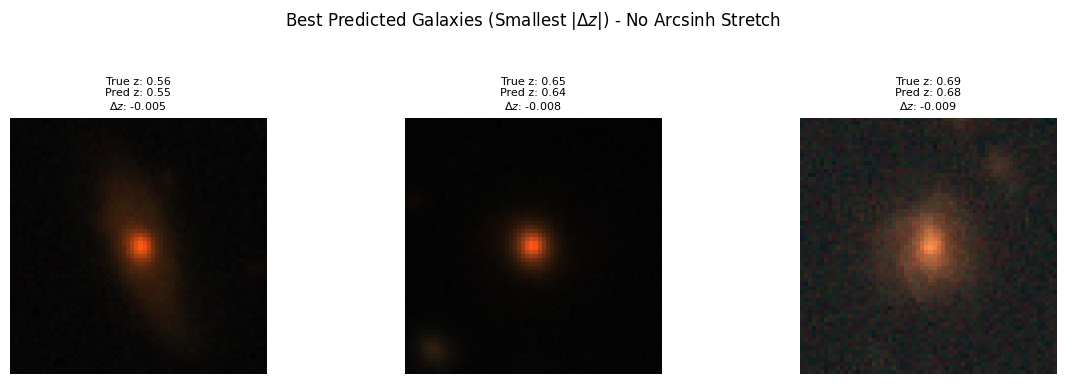

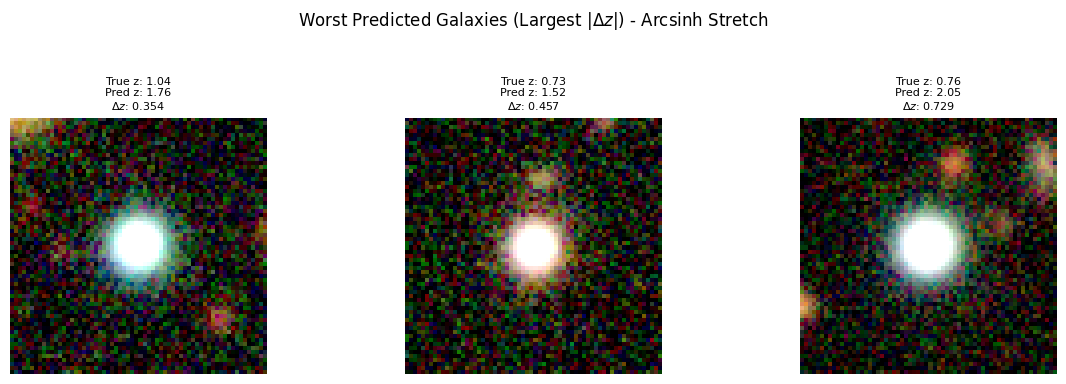

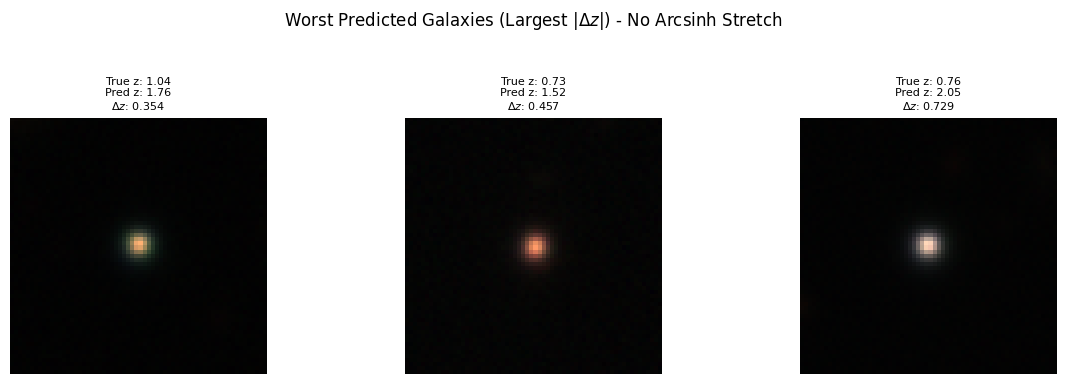


--- Analyzing Error Correlation with Redshift Range ---


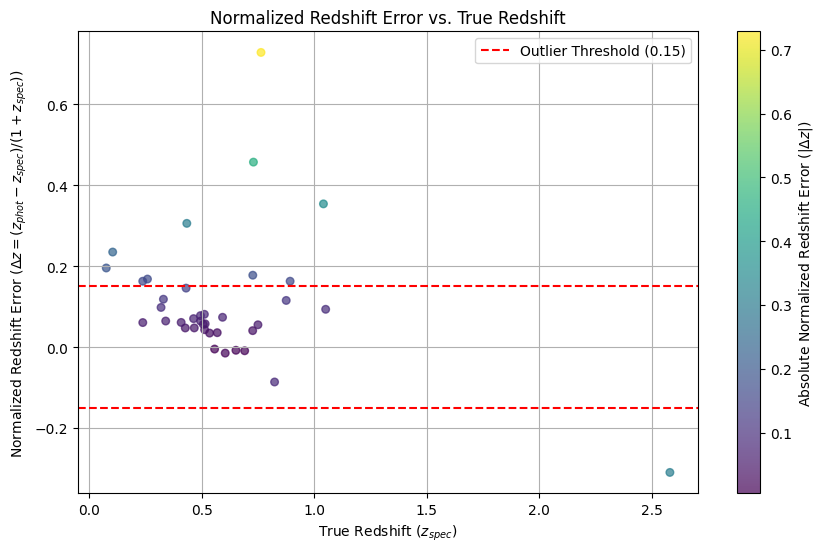


--- Analyzing Error Correlation with Image Quality Proxy ---


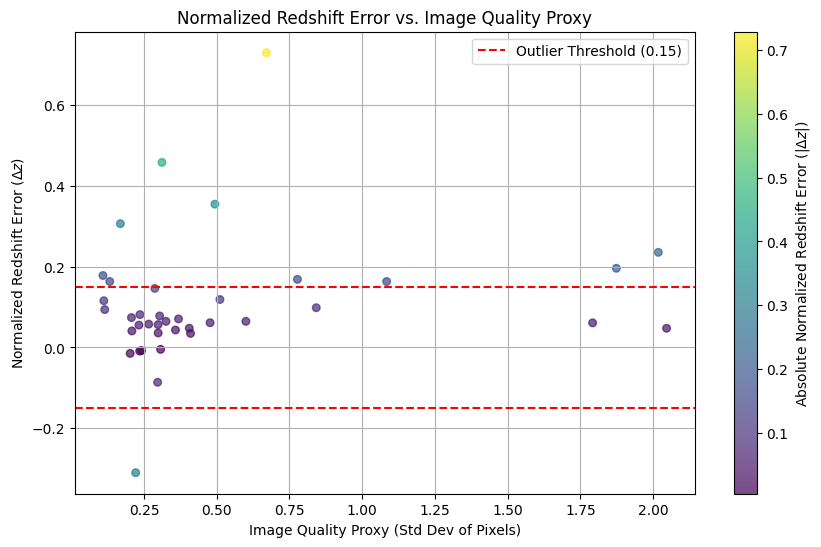

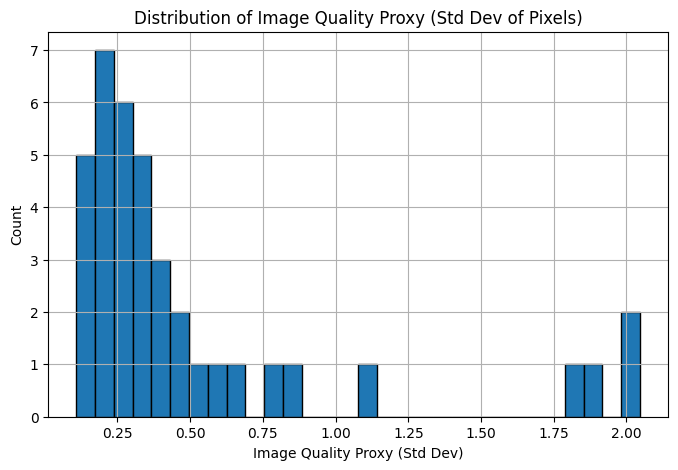

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Re-use variables from previous cells that are in the kernel state:
# all_predictions, all_true_redshifts, delta_z_norm
# X_test, channel_means, channel_stds

#######
# Define a function to visualize a single 5-channel normalized image as RGB
#######
def visualize_galaxy_image(normalized_img_5channel, channel_means, channel_stds, title="", ax=None, apply_arcsinh_stretch=True):
    """
    Converts a 5-channel normalized image back to a pseudo-color RGB image
    and displays it. Optionally applies arcsinh stretch.
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    # Reverse normalization to get approximate original values
    # normalized_img_5channel shape: (5, 64, 64)
    # channel_stds shape: (5,) --> reshape to (5,1,1) for broadcasting
    # channel_means shape: (5,) --> reshape to (5,1,1) for broadcasting
    img_unnormalized = (normalized_img_5channel * channel_stds[:, None, None]) + channel_means[:, None, None]

    # Common astronomical mapping: i-band to Red, r-band to Green, g-band to Blue
    # Assuming channels are ordered: 0=g, 1=r, 2=i, 3=z, 4=y
    # So, we select channels 2 (i), 1 (r), 0 (g) for [R, G, B]
    img_rgb_bands = img_unnormalized[[2, 1, 0], :, :]

    # Transpose to (H, W, C) for matplotlib imshow
    img_rgb = np.transpose(img_rgb_bands, (1, 2, 0))

    if apply_arcsinh_stretch:
        # Apply arcsinh stretch for better dynamic range visualization
        # A factor of 10 is a common choice for astronomical images.
        stretch_factor = 10
        normalized_img_display = np.arcsinh(img_rgb * stretch_factor) / np.arcsinh(stretch_factor)
    else:
        # Simple min-max normalization for display without arcsinh stretch
        min_val = img_rgb.min()
        max_val = img_rgb.max()
        if (max_val - min_val) == 0:
            normalized_img_display = np.zeros_like(img_rgb)
        else:
            normalized_img_display = (img_rgb - min_val) / (max_val - min_val)

    # Clip values to ensure they are within the displayable range [0, 1]
    normalized_img_display = np.clip(normalized_img_display, 0, 1)

    ax.imshow(normalized_img_display)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

#######
# Identify well-predicted and poorly-predicted galaxies
#######
# Using delta_z_norm from the previous evaluation cell

# Sort by absolute delta_z_norm to find best and worst predictions
sorted_indices = np.argsort(np.abs(delta_z_norm))

# Get indices for best predictions (smallest absolute error)
num_examples_to_show = 3 # Number of examples to display for each category
best_predicted_indices = sorted_indices[:num_examples_to_show]

# Get indices for worst predictions (largest absolute error)
worst_predicted_indices = sorted_indices[-num_examples_to_show:]

print(f"--- Visualizing {num_examples_to_show} Best and {num_examples_to_show} Worst Predicted Galaxies (With Arcsinh Stretch) ---")

#######
# Visualize best predicted galaxies (With Arcsinh Stretch)
#######
fig_best, axes_best = plt.subplots(1, num_examples_to_show, figsize=(4 * num_examples_to_show, 4))
fig_best.suptitle(f'Best Predicted Galaxies (Smallest |$\Delta z$|) - Arcsinh Stretch', fontsize=12)

for i, idx_test in enumerate(best_predicted_indices):
    img = X_test[idx_test] # Get the normalized 5-channel image from the test set
    true_z = all_true_redshifts[idx_test]
    pred_z = all_predictions[idx_test]
    error = delta_z_norm[idx_test]
    title = f"True z: {true_z:.2f}\nPred z: {pred_z:.2f}\n$\Delta z$: {error:.3f}"
    visualize_galaxy_image(img, channel_means, channel_stds, title=title, ax=axes_best[i], apply_arcsinh_stretch=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

print(f"\n--- Visualizing {num_examples_to_show} Best and {num_examples_to_show} Worst Predicted Galaxies (Without Arcsinh Stretch) ---")

########
# Visualize best predicted galaxies (Without Arcsinh Stretch)
########
fig_best_no_stretch, axes_best_no_stretch = plt.subplots(1, num_examples_to_show, figsize=(4 * num_examples_to_show, 4))
fig_best_no_stretch.suptitle(f'Best Predicted Galaxies (Smallest |$\Delta z$|) - No Arcsinh Stretch', fontsize=12)

for i, idx_test in enumerate(best_predicted_indices):
    img = X_test[idx_test]
    true_z = all_true_redshifts[idx_test]
    pred_z = all_predictions[idx_test]
    error = delta_z_norm[idx_test]
    title = f"True z: {true_z:.2f}\nPred z: {pred_z:.2f}\n$\Delta z$: {error:.3f}"
    visualize_galaxy_image(img, channel_means, channel_stds, title=title, ax=axes_best_no_stretch[i], apply_arcsinh_stretch=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


#######
# Visualize worst predicted galaxies (With Arcsinh Stretch)
#######
fig_worst, axes_worst = plt.subplots(1, num_examples_to_show, figsize=(4 * num_examples_to_show, 4))
fig_worst.suptitle(f'Worst Predicted Galaxies (Largest |$\Delta z$|) - Arcsinh Stretch', fontsize=12)

for i, idx_test in enumerate(worst_predicted_indices):
    img = X_test[idx_test]
    true_z = all_true_redshifts[idx_test]
    pred_z = all_predictions[idx_test]
    error = delta_z_norm[idx_test]
    title = f"True z: {true_z:.2f}\nPred z: {pred_z:.2f}\n$\Delta z$: {error:.3f}"
    visualize_galaxy_image(img, channel_means, channel_stds, title=title, ax=axes_worst[i], apply_arcsinh_stretch=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

#######
# Visualize worst predicted galaxies (Without Arcsinh Stretch)
#######
fig_worst_no_stretch, axes_worst_no_stretch = plt.subplots(1, num_examples_to_show, figsize=(4 * num_examples_to_show, 4))
fig_worst_no_stretch.suptitle(f'Worst Predicted Galaxies (Largest |$\Delta z$|) - No Arcsinh Stretch', fontsize=12)

for i, idx_test in enumerate(worst_predicted_indices):
    img = X_test[idx_test]
    true_z = all_true_redshifts[idx_test]
    pred_z = all_predictions[idx_test]
    error = delta_z_norm[idx_test]
    title = f"True z: {true_z:.2f}\nPred z: {pred_z:.2f}\n$\Delta z$: {error:.3f}"
    visualize_galaxy_image(img, channel_means, channel_stds, title=title, ax=axes_worst_no_stretch[i], apply_arcsinh_stretch=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

#######
# Check if errors correlate with redshift range
#######
print("\n--- Analyzing Error Correlation with Redshift Range ---")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(all_true_redshifts, delta_z_norm,
                      c=np.abs(delta_z_norm), cmap='viridis', s=30, alpha=0.7)
plt.colorbar(scatter, label='Absolute Normalized Redshift Error (|$\Delta z$|)')
# Add lines for the outlier threshold (reusing the value from the previous cell)
plt.axhline(outlier_threshold, color='red', linestyle='--', label=f'Outlier Threshold ({outlier_threshold})')
plt.axhline(-outlier_threshold, color='red', linestyle='--')
plt.xlabel('True Redshift ($z_{spec}$)')
plt.ylabel('Normalized Redshift Error ($\Delta z = (z_{phot} - z_{spec}) / (1 + z_{spec})$)')
plt.title('Normalized Redshift Error vs. True Redshift')
plt.grid(True)
plt.legend()
plt.show()

# --- 6. Check if errors correlate with image quality (proxy) ---
print("\n--- Analyzing Error Correlation with Image Quality Proxy ---")

# Simple proxy for image quality: standard deviation of pixel values across all channels
# X_test shape: (num_samples, channels, height, width)
# Reshape each image to a 1D array of pixels, then calculate std along the new axis
image_quality_proxy = np.std(X_test.reshape(X_test.shape[0], -1), axis=1)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(image_quality_proxy, delta_z_norm,
                      c=np.abs(delta_z_norm), cmap='viridis', s=30, alpha=0.7)
plt.colorbar(scatter, label='Absolute Normalized Redshift Error (|$\Delta z$|)')
# Add lines for the outlier threshold
plt.axhline(outlier_threshold, color='red', linestyle='--', label=f'Outlier Threshold ({outlier_threshold})')
plt.axhline(-outlier_threshold, color='red', linestyle='--')
plt.xlabel('Image Quality Proxy (Std Dev of Pixels)')
plt.ylabel('Normalized Redshift Error ($\Delta z$)')
plt.title('Normalized Redshift Error vs. Image Quality Proxy')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(image_quality_proxy, bins=30, edgecolor='black')
plt.title('Distribution of Image Quality Proxy (Std Dev of Pixels)')
plt.xlabel('Image Quality Proxy (Std Dev)')
plt.ylabel('Count')
plt.grid(True)
plt.show()